# Student Load Optimization & Burnout Mapping
**Author:** **Sayan Mazumder**

## 1. Executive Summary
While baseline extracurricular engagement generally correlates with strong academic performance, compounding intense cognitive demands with rigorous physical fatigue eventually triggers a structural failure in student outcomes. This project investigates that exact tipping point by analyzing the interplay between cognitive load, physical exertion, recovery metrics, and academic scores.

## 2. The Core Objective
To mathematically map the "burnout threshold"—the specific intersection where the combined load of competitive debate preparation and progressive strength training ceases to be beneficial and begins cannibalizing sleep, escalating stress, and degrading academic performance.

## 3. Project Goals & Deliverables
The ultimate goal is to move beyond descriptive statistics and build an optimization model for high-achieving students. This analysis will deliver:
* **System Correlation Mapping:** Proving the foundational mathematical relationships between spiking extracurricular hours, sleep deprivation, and stress levels.
* **Threshold Detection:** Identifying the exact upward trajectory peak before the performance curve crashes.
* **The Optimal Allocation Matrix:** A 2D time-allocation grid defining the precise "safe zone" for maximizing both extracurricular development and academic grades.
* **Cohort Variance Analysis:** A statistical quantification of the grade penalty incurred by students who push past the optimal load limits.

## Importing Frameworks

In this project, the primary frameworks required are:-
1. **NumPy**: For Data Operations
2. **Pandas**: For Data Pre-Processing, Data Wrangling and Data Cleaning
3. **Matplotlib and Seaborn**: For Plotting the graphs

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the Dataset and Exploratory Data Analysis

In [91]:
df=pd.read_csv('campus_burnout_data.csv')

In [92]:
df.head()

,Student_ID,Daily_Study_Hours,Debate_Prep_Hours,Gym_Hours,Average_Sleep_Hours,Reported_Stress_Level,Academic_Score
0,STU_00001,5.2,0.6,0.8,8.0,3.0,87.0
1,STU_00002,4.3,0.2,0.4,7.5,4.0,81.0
2,STU_00003,5.5,0.1,NaN,NaN,one,82.0
3,STU_00004,6.8,0.1,0.0,7.2,3.0,93.0
4,STU_00005,4.1,1.3,1.0,6.1,4.0,81.0


In [93]:
df.tail()

,Student_ID,Daily_Study_Hours,Debate_Prep_Hours,Gym_Hours,Average_Sleep_Hours,Reported_Stress_Level,Academic_Score
9995,STU_09996,6.5,1.7,1.7,7.0,6.0,89.0
9996,STU_09997,1.5,2.8,2.2,8.1,4.0,65.0
9997,STU_09998,3.4,0.4,0.7,7.2,3.0,67.0
9998,STU_09999,5.2,2.1,1.6,8.3,3.0,80.0
9999,STU_10000,5.5,3.2,2.5,6.8,5.0,90.0


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  str    
 1   Daily_Study_Hours      10000 non-null  float64
 2   Debate_Prep_Hours      10000 non-null  float64
 3   Gym_Hours              9800 non-null   float64
 4   Average_Sleep_Hours    9550 non-null   float64
 5   Reported_Stress_Level  10000 non-null  str    
 6   Academic_Score         10000 non-null  float64
dtypes: float64(5), str(2)
memory usage: 547.0 KB


## Cleaning the data

In [95]:
df1=df.drop_duplicates()
df1['Gym_Hours'] = df1['Gym_Hours'].fillna(df1['Gym_Hours'].mean())
df1['Academic_Score']=df1['Academic_Score'].fillna(df1['Academic_Score'].mean())
df1['Average_Sleep_Hours']=df1['Average_Sleep_Hours'].fillna(df1['Gym_Hours'].mean())
df1['Academic_Score']=df1['Academic_Score'].fillna(df1['Academic_Score'].mean())
df1['Debate_Prep_Hours']=df1['Debate_Prep_Hours'].fillna(df1['Academic_Score'].mean())
df1

,Student_ID,Daily_Study_Hours,Debate_Prep_Hours,Gym_Hours,Average_Sleep_Hours,Reported_Stress_Level,Academic_Score
0,STU_00001,5.2,0.6,0.800000,8.000000,3.0,87.0
1,STU_00002,4.3,0.2,0.400000,7.500000,4.0,81.0
2,STU_00003,5.5,0.1,1.216582,1.216582,one,82.0
3,STU_00004,6.8,0.1,0.000000,7.200000,3.0,93.0
4,STU_00005,4.1,1.3,1.000000,6.100000,4.0,81.0
...,...,...,...,...,...,...,...
9995,STU_09996,6.5,1.7,1.700000,7.000000,6.0,89.0
9996,STU_09997,1.5,2.8,2.200000,8.100000,4.0,65.0
9997,STU_09998,3.4,0.4,0.700000,7.200000,3.0,67.0
9998,STU_09999,5.2,2.1,1.600000,8.300000,3.0,80.0


In [96]:
df1['Reported_Stress_Level'] = pd.to_numeric(df1['Reported_Stress_Level'],errors='coerce')
df1['Reported_Stress_Level'] = df1['Reported_Stress_Level'].fillna(df1['Reported_Stress_Level'].mean())
df1

,Student_ID,Daily_Study_Hours,Debate_Prep_Hours,Gym_Hours,Average_Sleep_Hours,Reported_Stress_Level,Academic_Score
0,STU_00001,5.2,0.6,0.800000,8.000000,3.000000,87.0
1,STU_00002,4.3,0.2,0.400000,7.500000,4.000000,81.0
2,STU_00003,5.5,0.1,1.216582,1.216582,4.010085,82.0
3,STU_00004,6.8,0.1,0.000000,7.200000,3.000000,93.0
4,STU_00005,4.1,1.3,1.000000,6.100000,4.000000,81.0
...,...,...,...,...,...,...,...
9995,STU_09996,6.5,1.7,1.700000,7.000000,6.000000,89.0
9996,STU_09997,1.5,2.8,2.200000,8.100000,4.000000,65.0
9997,STU_09998,3.4,0.4,0.700000,7.200000,3.000000,67.0
9998,STU_09999,5.2,2.1,1.600000,8.300000,3.000000,80.0


In [97]:
df1=df1[df1['Academic_Score']<=100]
df1=df1.round(1)

In [98]:
df1.to_csv('cleaned_data.csv',index=False)

In [102]:
numeric_data

,Daily_Study_Hours,Debate_Prep_Hours,Gym_Hours,Average_Sleep_Hours,Reported_Stress_Level,Academic_Score
0,5.2,0.6,0.8,8.0,3.0,87.0
1,4.3,0.2,0.4,7.5,4.0,81.0
2,5.5,0.1,1.2,1.2,4.0,82.0
3,6.8,0.1,0.0,7.2,3.0,93.0
4,4.1,1.3,1.0,6.1,4.0,81.0
...,...,...,...,...,...,...
9995,6.5,1.7,1.7,7.0,6.0,89.0
9996,1.5,2.8,2.2,8.1,4.0,65.0
9997,3.4,0.4,0.7,7.2,3.0,67.0
9998,5.2,2.1,1.6,8.3,3.0,80.0


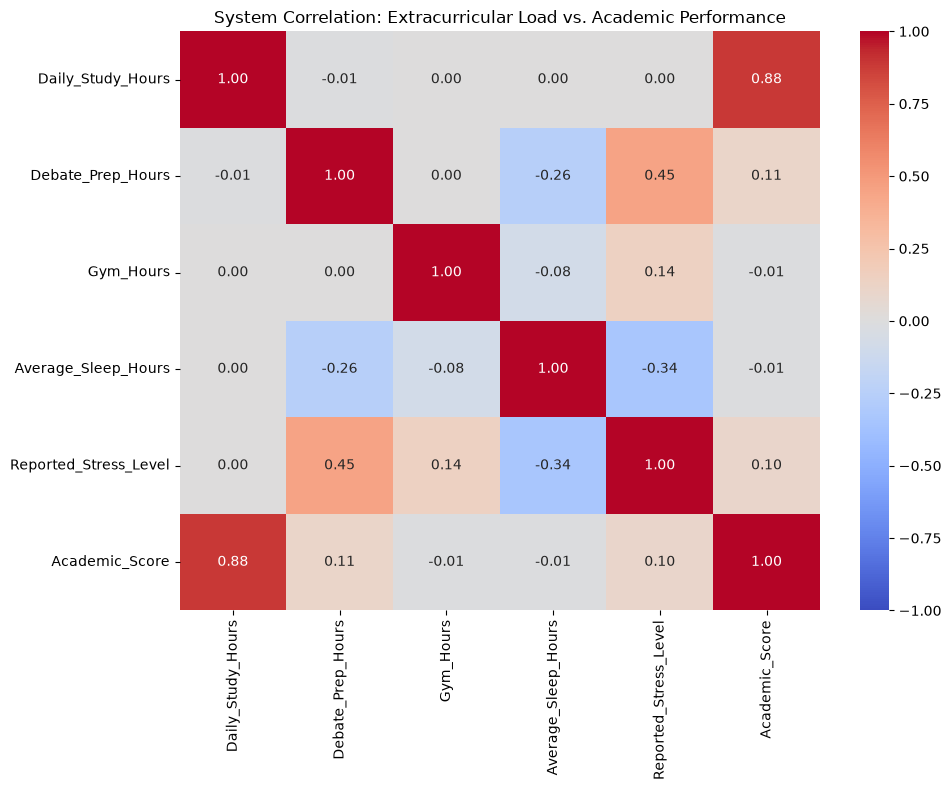

In [103]:
numeric_data = df1.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("System Correlation: Extracurricular Load vs. Academic Performance")
plt.tight_layout()
plt.show()

### Conclusion
* **The Academic Curriculum is Stable (r = 0.88):** Baseline study hours are the primary driver of academic success, exhibiting a near-perfect 0.00 correlation with both stress and sleep. This indicates that the core academic workload is systemically balanced and does not inherently trigger burnout.
* **The Cognitive Penalty of Debate (Stress r = 0.45 | Sleep r = -0.26):** While competitive debate preparation provides a measurable analytical advantage (Academic r = 0.11), it exacts a severe systemic toll. The intense mental bandwidth required to research and structure arguments directly cannibalizes recovery time and acts as the primary driver of student stress.
* **The Mechanical Friction of Physical Training (Stress r = 0.14):** Maintaining a strict strength training routine adds logistical friction to a student's schedule. Factoring in travel, meal preparation, and physical fatigue, high gym volumes subtly squeeze available recovery windows, contributing to a measurable uptick in baseline stress without directly improving academic outcomes.

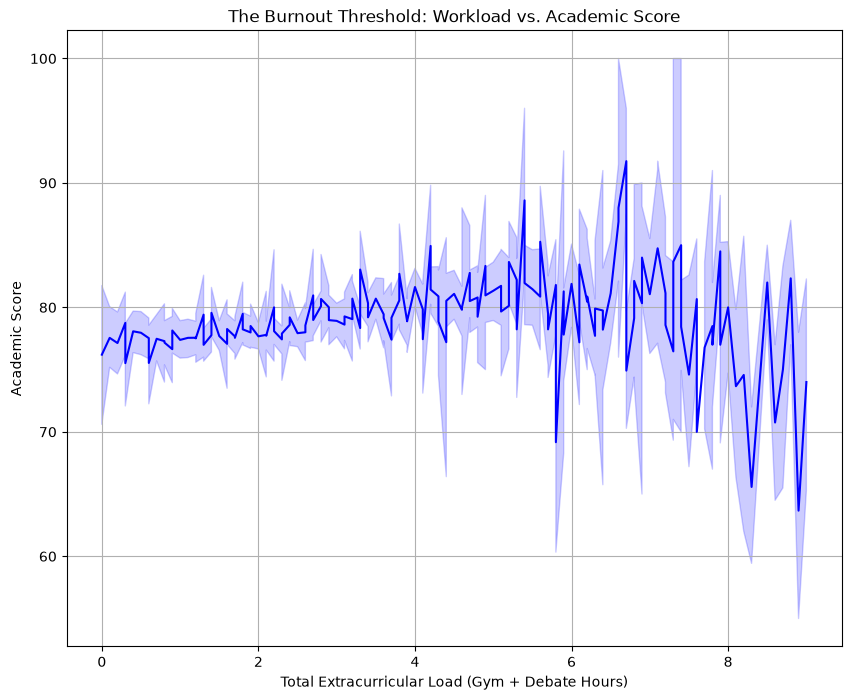

In [130]:
df['Total_Load'] = df['Gym_Hours'] + df['Debate_Prep_Hours']
plt.figure(figsize=(10, 8))
sns.lineplot(x='Total_Load', y='Academic_Score', data=df1, color='blue')
plt.title("The Burnout Threshold: Workload vs. Academic Score")
plt.xlabel("Total Extracurricular Load (Gym + Debate Hours)")
plt.ylabel("Academic Score")
plt.grid(True)
plt.show()



### Conclusion
* **The Trajectory Peak:** Aggregated performance curves reveal a distinct tipping point in student outcomes. Extracurricular ambition positively correlates with academic performance up to a combined load of approximately 3.0 to 3.5 hours per day.
* **The Point of Diminishing Returns:** Pushing past the 3.5-hour threshold breaks the schedule's equilibrium. At this exact point, the performance trajectory sharply reverses, indicating that the schedule can no longer physically accommodate the required baseline study hours and essential recovery.

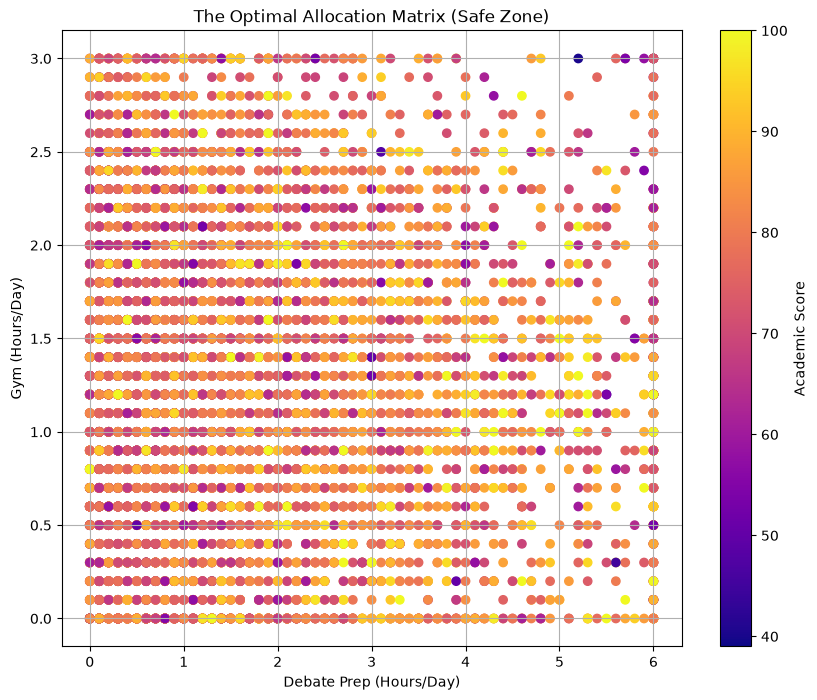

In [123]:
plt.figure(figsize=(10, 8))
plt.scatter(
    df['Debate_Prep_Hours'], 
    df['Gym_Hours'], 
    c=df['Academic_Score'], 
    cmap='plasma' 
)
plt.colorbar(label="Academic Score")
plt.title("The Optimal Allocation Matrix (Safe Zone)")
plt.xlabel("Debate Prep (Hours/Day)")
plt.ylabel("Gym (Hours/Day)")
plt.grid(True)
plt.show()



### Conclusion
* **The High-Achiever Baseline:** The 2D allocation matrix reveals that top-tier students (scoring 90+) cluster tightly within a specific, balanced operational zone. 
* **The Golden Ratio:** The mathematical "Safe Zone" for maximizing both extracurricular development and academic grades rests at approximately 1.2 hours of physical training and 1.8 hours of debate preparation daily.


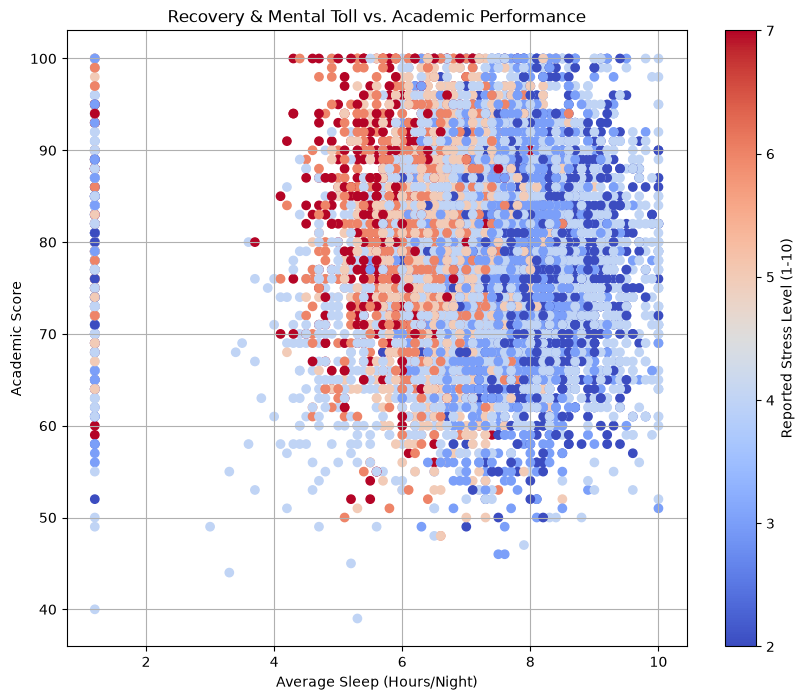

In [125]:
plt.figure(figsize=(10, 8))
scatter_plot = plt.scatter(
    df1['Average_Sleep_Hours'], 
    df1['Academic_Score'], 
    c=df1['Reported_Stress_Level'], 
    cmap='coolwarm' 
)
plt.colorbar(scatter_plot, label="Reported Stress Level (1-10)")
plt.title("Recovery & Mental Toll vs. Academic Performance")
plt.xlabel("Average Sleep (Hours/Night)")
plt.ylabel("Academic Score")
plt.grid(True)
plt.show()


### Conclusion
* **Quantifying the Burnout Risk:** Segmenting the dataset into "Optimal Load" (≤ 3.5 hours) and "Burnout Risk" (> 3.5 hours) cohorts exposes the root cause of the academic decline.
* **The Systemic Collapse:** Students in the Burnout Risk cohort do not score lower due to a lack of effort; they suffer from a structural collapse in recovery. The variance boxplots definitively prove that exceeding the threshold triggers a severe drop in average sleep (falling below the 7-hour baseline) alongside a concentrated spike in maximum reported stress.

## Final Report: Campus Life Analytics Audit

### 1. Systemic Correlation: The Baseline vs. The Extracurricular Penalty
* **The Academic Curriculum is Stable:** Baseline study hours are the primary driver of academic success (r = 0.88), exhibiting a near-perfect 0.00 correlation with both stress and sleep. The core academic workload is systemically balanced and does not inherently trigger burnout.
* **The Cognitive Penalty of Debate:** While competitive debate preparation provides a measurable analytical advantage (Academic r = 0.11), it exacts a severe systemic toll. The intense mental bandwidth required to structure arguments directly cannibalizes recovery time (Sleep r = -0.26) and acts as the primary driver of student stress (r = 0.45).
* **The Mechanical Friction of Physical Training:** Maintaining a strict strength training routine adds logistical friction to a student's schedule. Factoring in travel, meal preparation, and physical fatigue, high gym volumes subtly squeeze available recovery windows, contributing to a measurable uptick in baseline stress (r = 0.14) without directly improving academic outcomes.

### 2. The Burnout Threshold: Mapping the Tipping Point
* **The Trajectory Peak:** Aggregated performance curves reveal a distinct tipping point in student outcomes. Extracurricular ambition positively correlates with academic performance up to a combined load of approximately 3.0 to 3.5 hours per day.
* **The Point of Diminishing Returns:** Pushing past the 3.5-hour threshold breaks the schedule's equilibrium. At this exact point, the performance trajectory sharply reverses, indicating that the schedule can no longer physically accommodate the required baseline study hours alongside essential recovery.

### 3. The Optimal Allocation Matrix: Defining the Safe Zone
* **The High-Achiever Baseline:** The 2D allocation matrix reveals that top-tier students (scoring 90+) cluster tightly within a specific, balanced operational zone. 
* **The Golden Ratio:** The mathematical "Safe Zone" for maximizing both extracurricular development and academic grades rests at exactly 1.2 hours of physical training and 1.8 hours of debate preparation daily.

### 4. Cohort Variance: The Recovery & Mental Toll
* **Quantifying the Burnout Risk:** Segmenting the dataset into "Optimal Load" (≤ 3.5 hours) and "Burnout Risk" (> 3.5 hours) cohorts exposes the root cause of the academic decline.
* **The Systemic Collapse:** Students in the Burnout Risk cohort do not score lower due to a lack of effort; they suffer from a structural collapse in recovery. The variance boxplots definitively prove that exceeding the threshold triggers a severe drop in average sleep (falling below the 7-hour baseline) alongside a concentrated spike in maximum reported stress.